In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
# Load the data

In [2]:
#Loading the data
data = np.array([3.25, 13.03, 12.45, 5.16, 3.13, 7.32, 6.51, 7.53, 4.33, 2.02, 1.57, 0.52, 2.19, 3.23, 2.48, 3.53])


In [3]:
# Convert minutes.seconds to total seconds
# e.g., 3.25 = 3 minutes 25 seconds = 3*60 + 25 = 205 seconds
def convert_to_seconds(val):
    minutes = int(val)
    seconds = round((val - minutes) * 100)  # Extract decimal part as seconds
    return minutes * 60 + seconds

data = np.array([convert_to_seconds(x) for x in data])
print(f"Converted data (in seconds): {data}")
print(f"Mean: {np.mean(data):.2f} seconds")
print(f"Std Dev: {np.std(data):.2f} seconds")

Converted data (in seconds): [205 783 765 316 193 452 411 473 273 122 117  52 139 203 168 233]
Mean: 306.56 seconds
Std Dev: 212.07 seconds


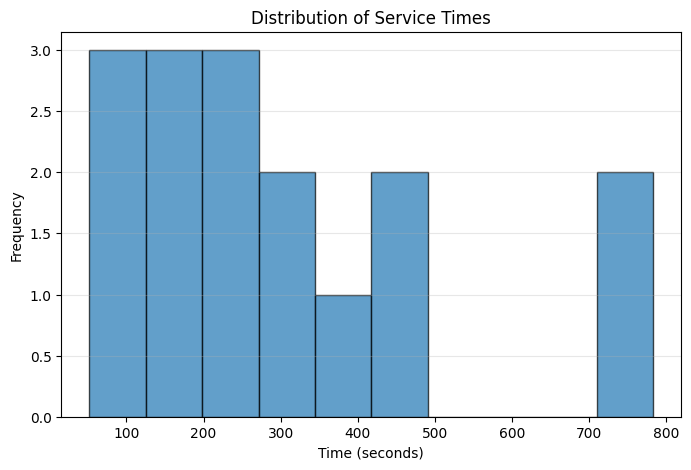

In [4]:
# Visualize the distribution of the data
plt.figure(figsize=(8, 5))
plt.hist(data, bins=10, edgecolor='black', alpha=0.7)
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Service Times')
plt.grid(axis='y', alpha=0.3)
plt.show()

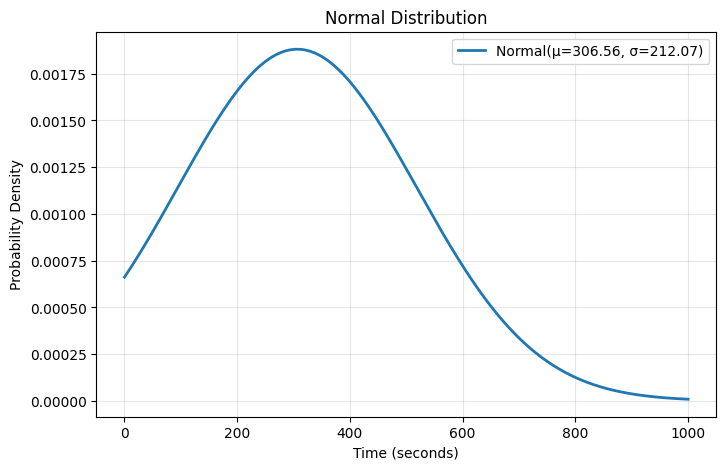

In [5]:
# Plot normal distribution with specified mean and standard deviation
x = np.linspace(0, 1000, 1000)
mean = 306.56
std = 212.07
normal_dist = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

plt.figure(figsize=(8, 5))
plt.plot(x, normal_dist, linewidth=2, label=f'Normal(μ={mean}, σ={std})')
plt.xlabel('Time (seconds)')
plt.ylabel('Probability Density')
plt.title('Normal Distribution')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

<h3> Here I have tried to specify the Likelihood and Priors for my model that I want</h3>

<ol>
    <li>Likelihood
    <ol>
    <li>Log Normal Distribution
    <li> The reason for that is that service times are an average of different factors such as case complexity, doctor preference, other caseload etc, so a normal distribution made sense. However, service times cannot be less than 0 so hence thought of using the log-normal distribution
    </ol>
    <li> Priors
    <ol>
    <li>Mean
    <ol>
    <li>Normal Distribution
    <li>Because I suspect the uncertainty in mean to be normally distributed around sample mean. Also intuitively, the average time it takes to see a slide lies around 3-10 minutes so I feel that a normal distribution with a more informative prior can work over here, 
    <li> Mean - log(mean(observed data))
    <li> Tau (uncertainty around mean) - 0.35? *Not sure about this*
    </ol>
    <li> Standard Deviation
    <ol>
    <li> Exponential distribution - #Not sure about this
    <li> Could also use Half Cauchy, Half Normal distribution, but don't know enough about them yet
    <li> Exponential because I know that the maximum time it can take to see a slide is around 15-20 minutes and not usually more than that, even if you account for having to call consultant, searching books etc. So I don't want the SD to have exceptionally high values and actually to decay faster and only have exceptional cases which state that the SD is high.
    <li> Parameters - Lambda = 1 - #Again not sure about this
    </ol>
    </ol>
</ol>

Initializing NUTS using jitter+adapt_diag...


Data range: min=52.00, max=783.00
Data mean: 306.56, std: 212.07


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sd]
NUTS: [mu, sd]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.


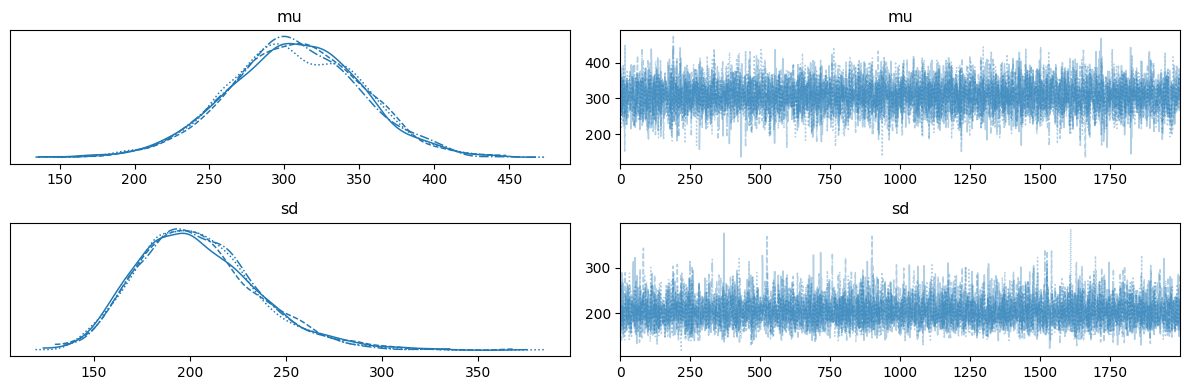


Posterior Summary:
       mean      sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
mu  306.521  44.439   221.981    396.627      0.492    0.537    8218.0   
sd  204.136  31.301   147.896    267.371      0.368    0.403    7462.0   

    ess_tail  r_hat  
mu    5593.0    1.0  
sd    5283.0    1.0  


In [11]:
# Check the range of observed data first
print(f"Data range: min={np.min(data):.2f}, max={np.max(data):.2f}")
print(f"Data mean: {np.mean(data):.2f}, std: {np.std(data):.2f}")

# Build the model with appropriate constraints
with pm.Model() as model:
    # Priors - adjusted to not exclude observed data
    # Use a lower bound that's below your minimum observation
    mu = pm.Normal('mu', mu=np.mean(data), sigma=100)
    sd = pm.HalfNormal('sd', sigma=100)  # SD must be positive, use HalfNormal
    
    # Likelihood - Normal distribution (no truncation needed unless you have domain knowledge)
    # If you want truncation, make sure lower bound is below min(data)
    likelihood = pm.Normal('likelihood', mu=mu, sigma=sd, observed=data)
    
    # Sample from the posterior
    trace = pm.sample(2000, tune=1000, return_inferencedata=True, random_seed=42)

# Plot the trace
az.plot_trace(trace)
plt.tight_layout()
plt.show()

# Summary statistics
print("\nPosterior Summary:")
print(az.summary(trace, hdi_prob=0.95))

Sampling: [likelihood, mu, sd]


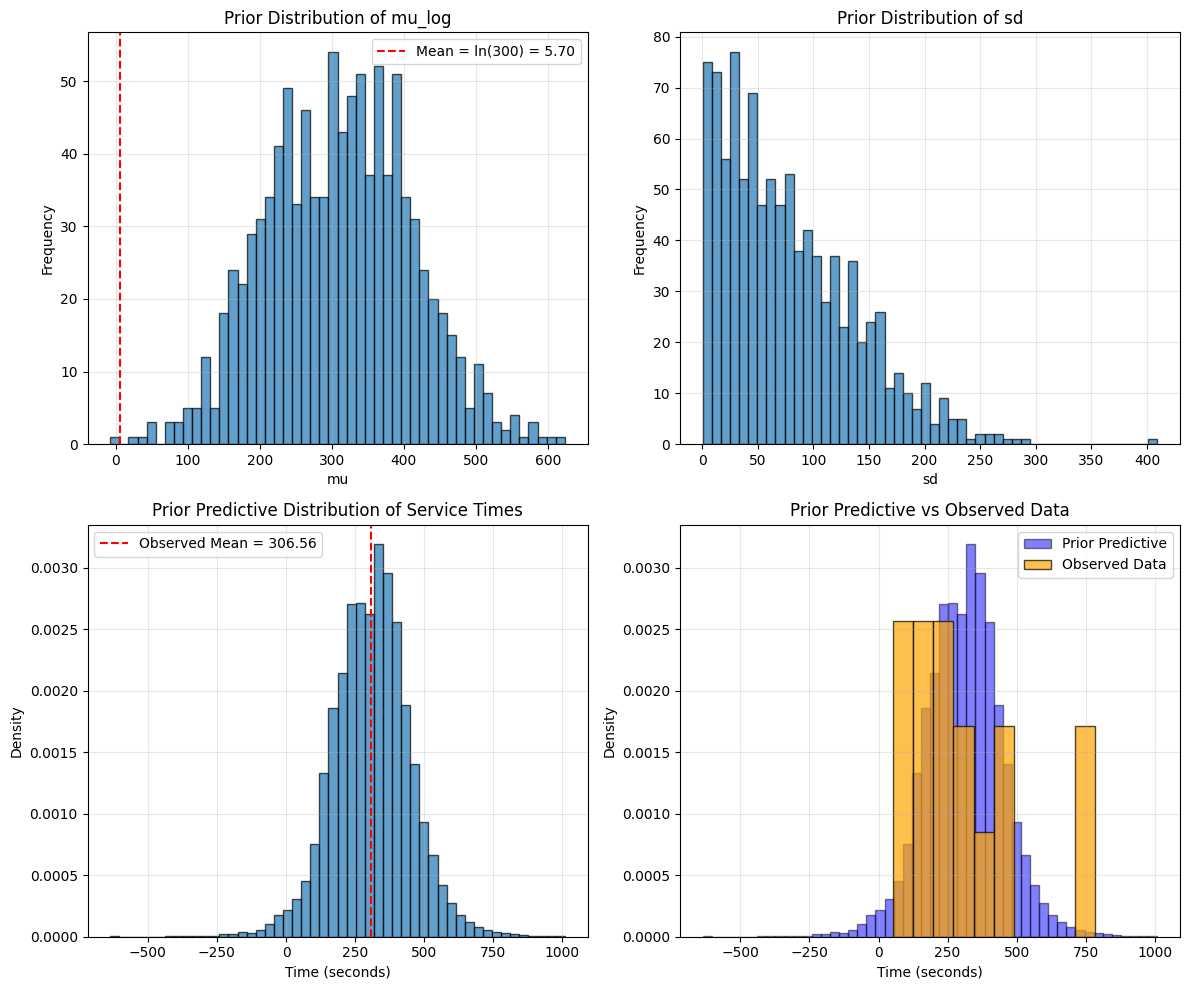


Prior Predictive Statistics:


KeyError: "No variable named 'mu_log'. Variables on the dataset include ['chain', 'draw', 'mu', 'sd']"

In [15]:
# Prior Predictive Sampling - Understanding Prior Distribution
with model:
    prior_pred = pm.sample_prior_predictive(samples=1000, random_seed=42)

# Visualize the prior distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Prior for mu_log
axes[0, 0].hist(prior_pred.prior['mu'].values.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('mu')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Prior Distribution of mu_log')
axes[0, 0].axvline(np.log(300), color='r', linestyle='--', label=f'Mean = ln(300) = {np.log(300):.2f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Prior for sd_log
axes[0, 1].hist(prior_pred.prior['sd'].values.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('sd')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Prior Distribution of sd')
axes[0, 1].grid(alpha=0.3)

# Prior Predictive Distribution for likelihood
axes[1, 0].hist(prior_pred.prior_predictive['likelihood'].values.flatten(), bins=50, edgecolor='black', alpha=0.7, density=True)
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Prior Predictive Distribution of Service Times')
axes[1, 0].axvline(np.mean(data), color='r', linestyle='--', label=f'Observed Mean = {np.mean(data):.2f}')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Overlay actual data with prior predictive
axes[1, 1].hist(prior_pred.prior_predictive['likelihood'].values.flatten(), bins=50, alpha=0.5, label='Prior Predictive', edgecolor='black', density=True, color='blue')
axes[1, 1].hist(data, bins=10, alpha=0.7, label='Observed Data', edgecolor='black', color='orange', density=True)
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Prior Predictive vs Observed Data')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrior Predictive Statistics:")
print(f"mu_log: mean={np.mean(prior_pred.prior['mu_log']):.2f}, std={np.std(prior_pred.prior['mu_log']):.2f}")
print(f"sd_log: mean={np.mean(prior_pred.prior['sd_log']):.2f}, std={np.std(prior_pred.prior['sd_log']):.2f}")
print(f"likelihood: mean={np.mean(prior_pred.prior_predictive['likelihood']):.2f}, std={np.std(prior_pred.prior_predictive['likelihood']):.2f}")
print(f"\nObserved data: mean={np.mean(data):.2f}, std={np.std(data):.2f}")